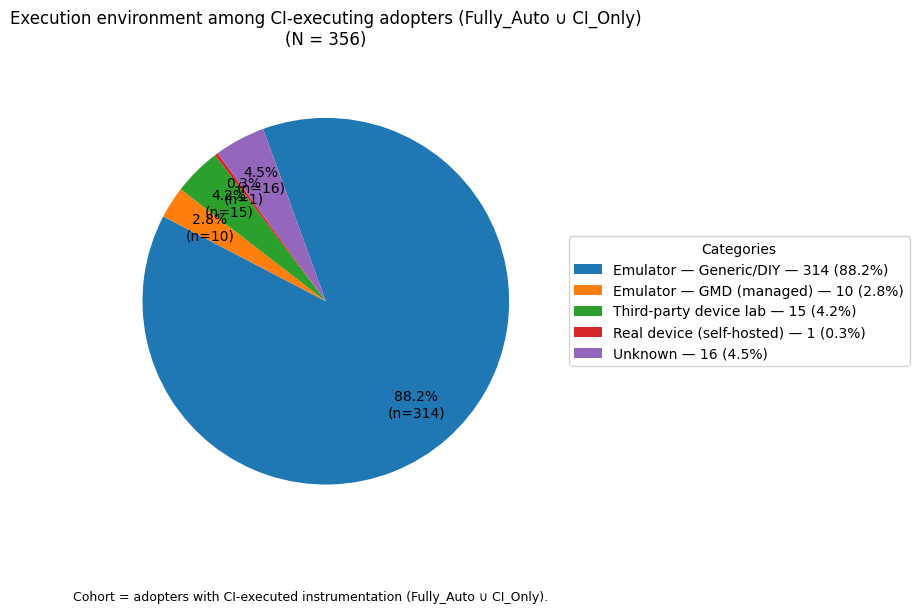

Dataset: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\5.0_Total_Repo_MR.csv
Cohort size (CI-executing): N=356
Counts: {'Emulator — Generic/DIY': 314, 'Emulator — GMD (managed)': 10, 'Third-party device lab': 15, 'Real device (self-hosted)': 1, 'Unknown': 16}


In [1]:
# -*- coding: utf-8 -*-
# Execution environment pie — aligned with Observation 3
# Cohort: CI-executing adopters (RQ1_F1 == True and RQ1_F2 in {Fully_Auto, CI_Only})
# One primary environment per repo (use ..._MR if present). Includes “Unknown”.
# Sums to 100% over the CI-executing cohort.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ========= CONFIG =========
MODE = "legend"  # "legend" or "labels"
WINDOWS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1")
PRIORITY_FILES = [
    "5.0_Total_Repo_MR.csv", "5.0_Total_Repo.csv",
    "3.2_Total_Repo_MR.csv", "3.2_Total_Repo.csv",
    "Total_Repo_MR.csv", "Total_Repo.csv",
]
FALLBACKS = [
    Path("/mnt/data/5.0_Total_Repo_MR.csv"),
    Path("/mnt/data/5.0_Total_Repo.csv"),
    Path("/mnt/data/3.2_Total_Repo_MR.csv"),
    Path("/mnt/data/3.2_Total_Repo.csv"),
]
SAVE_TO = None  # e.g., r"C:\Android Mobile App\figs\obs3_env_pie.png"
TITLE = "Execution environment among CI-executing adopters (Fully_Auto ∪ CI_Only)"

def choose_dataset_path():
    if WINDOWS_DIR.exists():
        for name in PRIORITY_FILES:
            p = WINDOWS_DIR / name
            if p.exists():
                return p
        csvs = sorted(WINDOWS_DIR.glob("*.csv"))
        if csvs:
            return csvs[0]
    for p in FALLBACKS:
        if p.exists():
            return p
    raise FileNotFoundError("Dataset not found in the Windows path or fallbacks.")

# Map normalized environment labels (single primary per repo)
def normalize_env(value: str) -> str:
    s = ("" if pd.isna(value) else str(value)).strip().lower()
    if s == "" or s == "unknown" or s == "none":
        return "Unknown"
    if "gmd" in s:
        return "Emulator — GMD (managed)"
    if "third" in s:
        return "Third-party device lab"
    if "real" in s:
        return "Real device (self-hosted)"
    if "emulator" in s:
        return "Emulator — Generic/DIY"
    # Fallback for unexpected tokens
    return "Unknown"

# ========= LOAD & COHORT =========
csv_path = choose_dataset_path()
df = pd.read_csv(csv_path, low_memory=False)

# Required columns
for col in ["RQ1_F1", "RQ1_F2"]:
    if col not in df.columns:
        raise KeyError(f"Expected '{col}' in dataset.")

# Prefer MR columns (tie-resolved)
env_col = "execution_environment_MR" if "execution_environment_MR" in df.columns else "execution_environment"
if env_col not in df.columns:
    raise KeyError("Expected execution environment column not found (…_MR or base).")

# CI-executing adopters
cohort = df[(df["RQ1_F1"] == True) & (df["RQ1_F2"].isin(["Fully_Auto", "CI_Only"]))].copy()
N_ci = len(cohort)

# Normalize environment labels (single value per repo)
cohort["env_norm"] = cohort[env_col].map(normalize_env)

# Fixed order to match the paper
order = [
    "Emulator — Generic/DIY",
    "Emulator — GMD (managed)",
    "Third-party device lab",
    "Real device (self-hosted)",
    "Unknown",
]

counts = cohort["env_norm"].value_counts().reindex(order, fill_value=0)
labels = [lab for lab, c in counts.items() if c > 0]
values = [c for c in counts.values if c > 0]

def autopct_counts(total):
    def _fmt(pct):
        # matplotlib passes percentage; we look up index via internal counter
        idx = _fmt.i
        _fmt.i += 1
        n = values[idx]
        return f"{(n/total*100):.1f}%\n(n={n})"
    _fmt.i = 0
    return _fmt

# ========= PLOT =========
title_text = f"{TITLE}\n(N = {N_ci})"

if MODE == "labels":
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_axes([0.06, 0.06, 0.88, 0.88])
    ax.pie(
        values,
        labels=labels,
        autopct=autopct_counts(N_ci),
        startangle=110,
        counterclock=False,
        labeldistance=1.12,
        pctdistance=0.72,
    )
    ax.set_title(title_text, pad=26)
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])
elif MODE == "legend":
    fig = plt.figure(figsize=(9, 6.8))
    ax = fig.add_subplot(111)
    wedges, _, _ = ax.pie(
        values,
        labels=None,
        autopct=autopct_counts(N_ci),
        startangle=110,
        counterclock=False,
        pctdistance=0.75,
    )
    ax.set_title(title_text, pad=20)
    legend_labels = [f"{lab} — {values[i]} ({values[i]/N_ci*100:.1f}%)" for i, lab in enumerate(labels)]
    ax.legend(
        wedges, legend_labels,
        loc="center left", bbox_to_anchor=(1.0, 0.5),
        borderaxespad=1.0, title="Categories",
    )
    fig.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])
else:
    raise ValueError("MODE must be 'legend' or 'labels'.")

# Helpful footer
fig.text(0.01, 0.01, "Cohort = adopters with CI-executed instrumentation (Fully_Auto ∪ CI_Only).", 
         ha="left", va="bottom", fontsize=9)

if SAVE_TO:
    plt.savefig(SAVE_TO, dpi=220, bbox_inches="tight")
plt.show()

print(f"Dataset: {csv_path}")
print(f"Cohort size (CI-executing): N={N_ci}")
print("Counts:", counts.to_dict())


In [2]:
# -*- coding: utf-8 -*-
"""
Build the Fully vs. Semi automation summary table from your main dataset.

Reads the CSV from:
C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1

Outputs a pandas DataFrame with columns:
Metric | Q1 (Fully) | Median (Fully) | Q3 (Fully) | Q1 (Semi) | Median (Semi) | Q3 (Semi)

Notes
- Uses RQ1_F1 == True to select adopters.
- Uses RQ1_F2 == 'Fully_Auto' vs 'Semi_Auto' to split classes.
- Derives rate metrics safely (avoids divide-by-zero).
- Prefers commits from 'commits_GitAPI' if present, else 'local_commit_count'.
- Prefers stars/forks from common GitHub field names.
"""

from pathlib import Path
import numpy as np
import pandas as pd

# -------- configuration --------
WINDOWS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1")
PRIORITY_FILES = [
    "3.2_Total_Repo_MR.csv",
    "3.2_Total_Repo.csv",
    "Total_Repo_MR.csv",
    "Total_Repo.csv",
]
# Optional fallback if you want to run this in another environment where a copy exists:
FALLBACKS = [Path("/mnt/data/3.2_Total_Repo_MR.csv"), Path("/mnt/data/3.2_Total_Repo.csv")]

# Column candidates (adjust/add if your schema differs)
COLS = {
    "prs": ["pull_requests", "prs", "total_prs"],
    "commits": ["commits_GitAPI", "local_commit_count", "commits"],
    "contributors": ["contributors", "num_contributors"],
    "age_years": ["repo_age", "age_years"],
    "size": ["size", "code_size", "loc"],
    "stars": ["stargazers_count", "stars"],
    "forks": ["forks_count", "forks"],
    "class": ["RQ1_F2", "automation_class", "class_f2"],
    "adopter": ["RQ1_F1", "Adopted_Primary", "adopted_primary", "is_adopter"],
}

# -------- helpers --------
def choose_dataset_path():
    if WINDOWS_DIR.exists():
        for name in PRIORITY_FILES:
            p = WINDOWS_DIR / name
            if p.exists():
                return p
        # otherwise first CSV in the folder (prefer names containing 'repo')
        csvs = sorted(WINDOWS_DIR.glob("*.csv"))
        for p in csvs:
            if "repo" in p.name.lower():
                return p
        if csvs:
            return csvs[0]
    for p in FALLBACKS:
        if p.exists():
            return p
    raise FileNotFoundError("Dataset not found in the Windows path or fallbacks.")

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the expected columns found: {candidates}")
    return None

def safe_div(num, den):
    # elementwise division with protection
    num = num.astype(float)
    den = den.astype(float)
    out = np.where((den > 0) & np.isfinite(den), num / den, np.nan)
    return pd.Series(out, index=num.index)

def q123(series):
    # return Q1, Median, Q3 on non-NaN values
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan, np.nan, np.nan
    return (np.quantile(s, 0.25), np.quantile(s, 0.50), np.quantile(s, 0.75))

def fmt(x):
    # pretty formatting: integers without .0, else two decimals
    if pd.isna(x):
        return ""
    if abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return f"{x:.2f}"

# -------- load --------
csv_path = choose_dataset_path()
df = pd.read_csv(csv_path)

adopter_col = first_existing(df, COLS["adopter"])
class_col = first_existing(df, COLS["class"])
prs_col = first_existing(df, COLS["prs"])
commits_col = first_existing(df, COLS["commits"])
contributors_col = first_existing(df, COLS["contributors"])
age_col = first_existing(df, COLS["age_years"])
size_col = first_existing(df, COLS["size"], required=False)
stars_col = first_existing(df, COLS["stars"], required=False)
forks_col = first_existing(df, COLS["forks"], required=False)

# -------- filter adopters and split classes --------
adopters = df[df[adopter_col] == True].copy()
# Normalize class labels if needed
class_map = {
    "Fully_Auto": "Fully",
    "Semi_Auto": "Semi",
    "CI_Only": "CI_Only",
    "Fully": "Fully",
    "Semi": "Semi",
}
adopters["Class"] = adopters[class_col].map(class_map).fillna(adopters[class_col])

fully = adopters[adopters["Class"] == "Fully"].copy()
semi = adopters[adopters["Class"] == "Semi"].copy()

# -------- derive metrics --------
# base columns
prs_f, prs_s = fully[prs_col], semi[prs_col]
comm_f, comm_s = fully[commits_col], semi[commits_col]
contrib_f, contrib_s = fully[contributors_col], semi[contributors_col]
age_f, age_s = fully[age_col], semi[age_col]

# per-year
prs_per_year_f = safe_div(prs_f, age_f)
prs_per_year_s = safe_div(prs_s, age_s)
comm_per_year_f = safe_div(comm_f, age_f)
comm_per_year_s = safe_div(comm_s, age_s)

# per-contributor
prs_per_contrib_f = safe_div(prs_f, contrib_f)
prs_per_contrib_s = safe_div(prs_s, contrib_s)
comm_per_contrib_f = safe_div(comm_f, contrib_f)
comm_per_contrib_s = safe_div(comm_s, contrib_s)

# commits per PR (granularity)
comm_per_pr_f = safe_div(comm_f, prs_f)
comm_per_pr_s = safe_div(comm_s, prs_s)

# optional fields
size_f = fully[size_col] if size_col else pd.Series(dtype=float)
size_s = semi[size_col] if size_col else pd.Series(dtype=float)
stars_f = fully[stars_col] if stars_col else pd.Series(dtype=float)
stars_s = semi[stars_col] if stars_col else pd.Series(dtype=float)
forks_f = fully[forks_col] if forks_col else pd.Series(dtype=float)
forks_s = semi[forks_col] if forks_col else pd.Series(dtype=float)

# -------- assemble Q1/Median/Q3 table --------
rows = [
    ("PRs/Year",            *q123(prs_per_year_f),        *q123(prs_per_year_s)),
    ("Commits/Year",        *q123(comm_per_year_f),       *q123(comm_per_year_s)),
    ("Commits/PR",          *q123(comm_per_pr_f),         *q123(comm_per_pr_s)),
    ("PRs/Contributor",     *q123(prs_per_contrib_f),     *q123(prs_per_contrib_s)),
    ("Commits/Contributor", *q123(comm_per_contrib_f),    *q123(comm_per_contrib_s)),
    ("PRs",                 *q123(prs_f),                 *q123(prs_s)),
    ("Commits",             *q123(comm_f),                *q123(comm_s)),
    ("Contributors",        *q123(contrib_f),             *q123(contrib_s)),
    ("AgeYears",            *q123(age_f),                 *q123(age_s)),
    ("Size",                *q123(size_f),                *q123(size_s)),
    ("Stars",               *q123(stars_f),               *q123(stars_s)),
    ("Forks",               *q123(forks_f),               *q123(forks_s)),
]

out = pd.DataFrame(
    rows,
    columns=[
        "Metric",
        "Q1 (Fully)", "Median (Fully)", "Q3 (Fully)",
        "Q1 (Semi)",  "Median (Semi)",  "Q3 (Semi)"
    ],
)

# Pretty-format numbers as strings (to mirror your example)
for col in out.columns[1:]:
    out[col] = out[col].map(fmt)

print(f"Dataset used: {csv_path}")
print(f"Fully n={len(fully)}, Semi n={len(semi)}")
print(out.to_string(index=False))

# Optional: save to CSV/Excel
out.to_csv(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\obs2_fully_vs_semi_table.csv", index=False)
# out.to_excel(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\obs2_fully_vs_semi_table.xlsx", index=False)


Dataset used: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ1\5.0_Total_Repo_MR.csv
Fully n=324, Semi n=1188
             Metric Q1 (Fully) Median (Fully) Q3 (Fully) Q1 (Semi) Median (Semi) Q3 (Semi)
           PRs/Year       2.33          13.24      62.94      0.65          4.43     29.42
       Commits/Year      23.12          69.73     257.36     13.40         50.68    204.61
         Commits/PR       2.23           5.42      14.69      3.36          7.59     21.30
    PRs/Contributor       2.71           7.55      19.46      1.25          3.79        12
Commits/Contributor      24.21          47.93     107.71     21.65         47.22    107.53
                PRs         14             85     370.50         3            20    129.25
            Commits     155.50         471.50    1504.50        72           258    903.75
       Contributors          3              9         32         2             4        13
           AgeYears       4.52           7.38      